### Импорт библиотек

In [1]:
import matplotlib.pyplot as plt
import mglearn
from scipy.io import loadmat
from sklearn import svm
from itertools import product

# Часть 3: Подбор параметров SVM для решения задачи нелинейной разделимости

### Загрузка данных

In [2]:
data = loadmat('data/ex4data3.mat')
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y', 'yval', 'Xval'])

### Инициализация векторов

In [3]:
X = data["X"]
y = data["y"].ravel()
Xval = data["Xval"]
yval = data["yval"].ravel()

### Визуализация данных

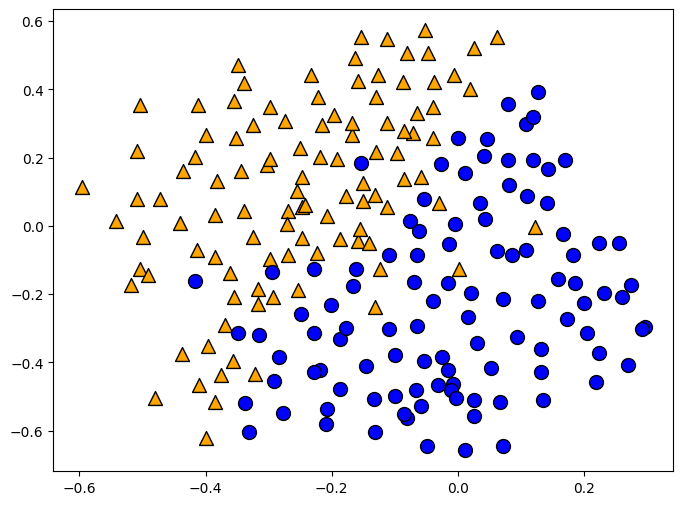

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:,0][y == 1], X[:,1][y == 1], marker="^", s=100, facecolor='orange', edgecolors='black')
plt.scatter(X[:,0][y == 0], X[:,1][y == 0], marker="o", s=100, facecolor='blue', edgecolors='black')
plt.show()

### Функция обучения SVC классификатора

In [5]:
def fit_svc_classifier(X, y, kernel, C, gamma, verbose=True) -> svm.SVC:
    svc_classifier = svm.SVC(kernel=kernel, C=C, gamma=gamma)
    svc_classifier.fit(X, y)
    if verbose:
        print(f'Score: {svc_classifier.score(X, y)}')
    return svc_classifier

### Функция отображения графика разделения выборки SVC классификатором

In [6]:
def svc_classifier_plot(svc_classifier, X, y, eps=.5):
    mglearn.plots.plot_2d_separator(svc_classifier, X, eps=eps)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y)

### Подбор оптимальных параметров C и gamma нелинейного классификатора таким образом, чтобы точность его работы на проверочном наборе данных была как можно больше

In [7]:
C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
gamma_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

best_model, best_score, best_params = None, 0, dict()
worst_model, worst_score, worst_params = None, 1, dict()
values = []

for C, gamma in product(C_values, gamma_values):
    svm_classifier = fit_svc_classifier(X, y, "rbf", C, gamma, verbose=False)
    score = svm_classifier.score(Xval, yval)
    values.append(score)

    if score > best_score:
        best_model, best_score = svm_classifier, score
        best_params = {'C': C, 'gamma': gamma}

    if score < worst_score:
        worst_model, worst_score = svm_classifier, score
        worst_params = {'C': C, 'gamma': gamma}

print(f'Values: {values}')
print(f'Best score: {best_score}, best params: {best_params}')
print(f'Worst score: {worst_score}, worst params: {worst_params}')

Values: [0.435, 0.435, 0.435, 0.435, 0.435, 0.435, 0.435, 0.435, 0.435, 0.435, 0.435, 0.435, 0.435, 0.795, 0.83, 0.895, 0.69, 0.435, 0.435, 0.435, 0.465, 0.815, 0.845, 0.895, 0.925, 0.95, 0.86, 0.435, 0.435, 0.82, 0.86, 0.91, 0.93, 0.955, 0.96, 0.965, 0.5, 0.82, 0.86, 0.91, 0.94, 0.95, 0.95, 0.96, 0.965, 0.82, 0.86, 0.915, 0.935, 0.925, 0.96, 0.955, 0.965, 0.945, 0.865, 0.915, 0.93, 0.935, 0.925, 0.95, 0.95, 0.95, 0.945, 0.915, 0.925, 0.935, 0.92, 0.935, 0.95, 0.965, 0.96, 0.92, 0.93, 0.935, 0.93, 0.925, 0.935, 0.955, 0.95, 0.95, 0.88]
Best score: 0.965, best params: {'C': 0.3, 'gamma': 100}
Worst score: 0.435, worst params: {'C': 0.01, 'gamma': 0.01}


### Отображение графика разделения тренировочной выборки с помощью лучшего SVC классификатора

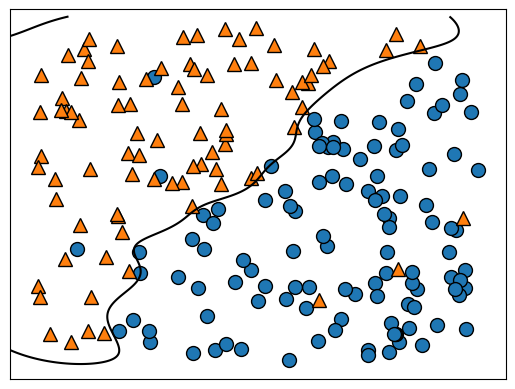

In [8]:
svc_classifier_plot(best_model, Xval, yval, .05)

### Отображение графика разделения тренировочной выборки с помощью худшего SVC классификатора

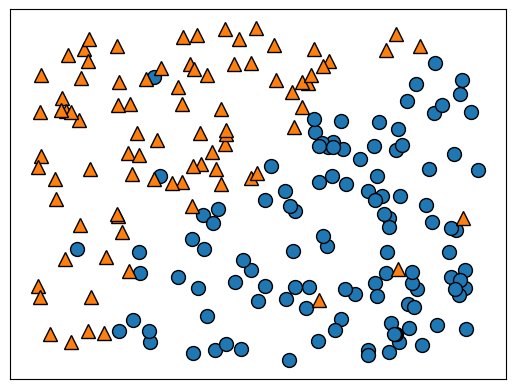

In [9]:
svc_classifier_plot(worst_model, Xval, yval, .05)

### Обучение SVC классификатора с `C = 0.3` и `gamma = 100`

In [10]:
random_svc_classifier = fit_svc_classifier(X, y, "rbf", 0.3, 100)

Score: 0.95260663507109


### Результат работы SVC классификатора на тренировочной выборке

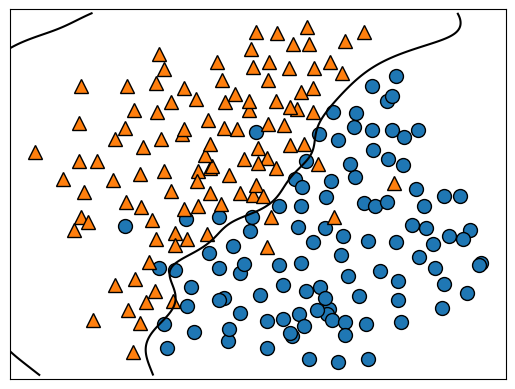

In [11]:
svc_classifier_plot(random_svc_classifier, X, y, .05)

### Результат работы SVC классификатора на тестовой выборке

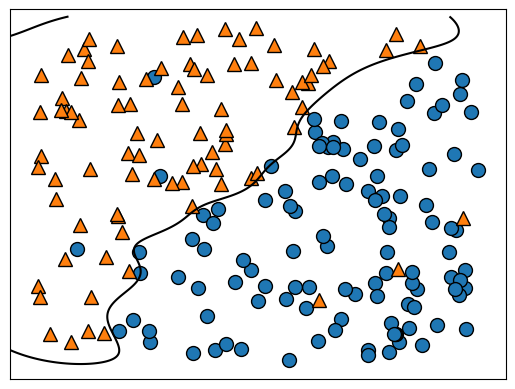

In [12]:
svc_classifier_plot(random_svc_classifier, Xval, yval, .05)

### Обучение SVC классификатора с `C = 10` и `gamma = 100`

In [13]:
random_svc_classifier = fit_svc_classifier(X, y, "rbf", 10, 100)

Score: 0.9620853080568721


### Результат работы SVC классификатора на тренировочной выборке

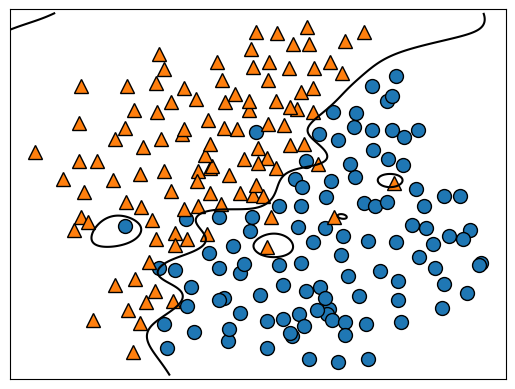

In [14]:
svc_classifier_plot(random_svc_classifier, X, y, .05)

### Результат работы SVC классификатора на тестовой выборке

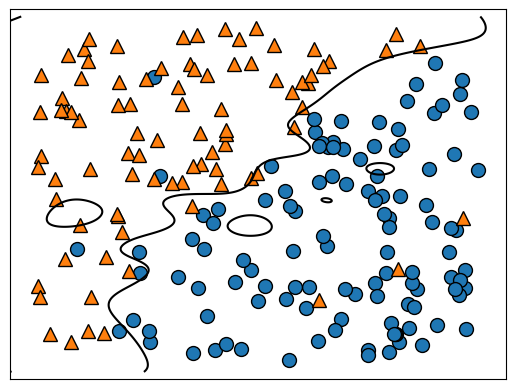

In [15]:
svc_classifier_plot(random_svc_classifier, Xval, yval, .05)

### Обучение SVC классификатора с `C = 100` и `gamma = 100`

In [16]:
random_svc_classifier = fit_svc_classifier(X, y, "rbf", 100, 100)

Score: 0.995260663507109


### Результат работы SVC классификатора на тренировочной выборке

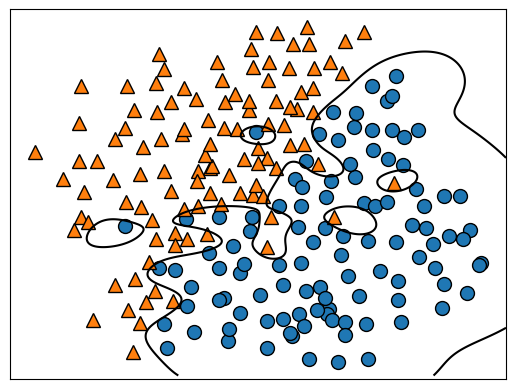

In [17]:
svc_classifier_plot(random_svc_classifier, X, y, .05)

### Результат работы SVC классификатора на тестовой выборке

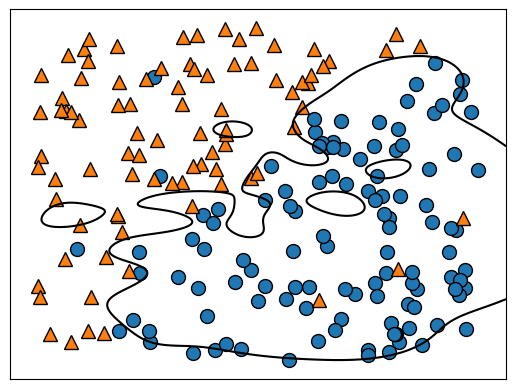

In [18]:
svc_classifier_plot(random_svc_classifier, Xval, yval, .05)

### Обучение SVC классификатора с `C = 0.3` и `gamma = 0.3`

In [19]:
random_svc_classifier = fit_svc_classifier(X, y, "rbf", 0.3, 0.3)

Score: 0.8625592417061612


### Результат работы SVC классификатора на тренировочной выборке

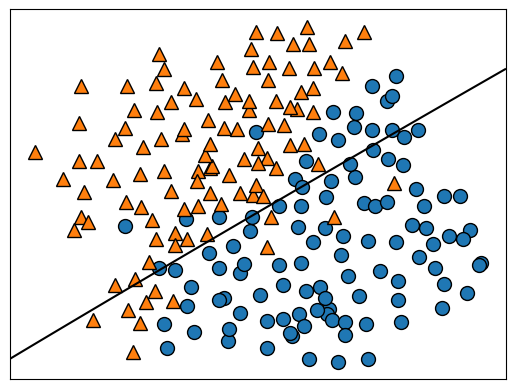

In [20]:
svc_classifier_plot(random_svc_classifier, X, y, .05)

### Результат работы SVC классификатора на тестовой выборке

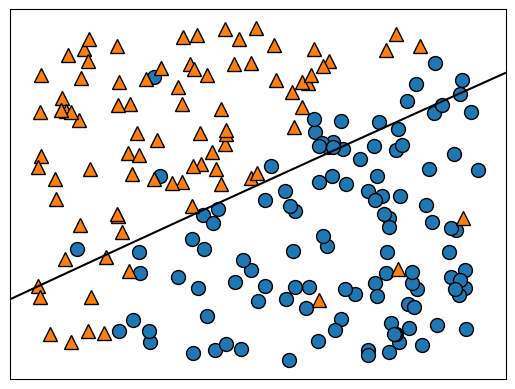

In [21]:
svc_classifier_plot(random_svc_classifier, Xval, yval, .05)

### Обучение SVC классификатора с `C = 0.3` и `gamma = 1`

In [22]:
random_svc_classifier = fit_svc_classifier(X, y, "rbf", 0.3, 1)

Score: 0.8767772511848341


### Результат работы SVC классификатора на тренировочной выборке

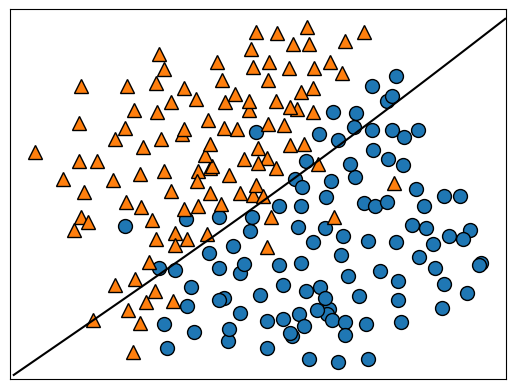

In [23]:
svc_classifier_plot(random_svc_classifier, X, y, .05)

### Результат работы SVC классификатора на тестовой выборке

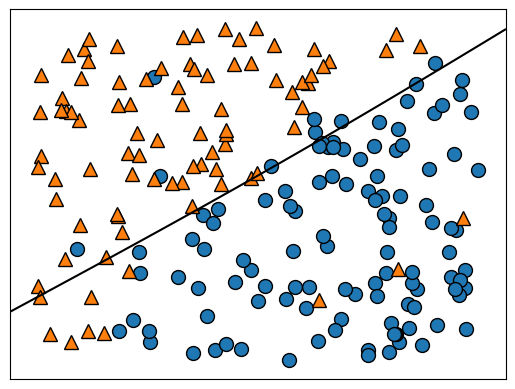

In [24]:
svc_classifier_plot(random_svc_classifier, Xval, yval, .05)

### Обучение SVC классификатора с `C = 0.3` и `gamma = 10`

In [25]:
random_svc_classifier = fit_svc_classifier(X, y, "rbf", 0.3, 10)

Score: 0.9289099526066351


### Результат работы SVC классификатора на тренировочной выборке

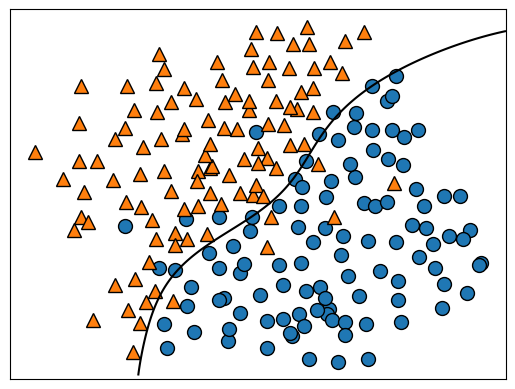

In [26]:
svc_classifier_plot(random_svc_classifier, X, y, .05)

### Результат работы SVC классификатора на тестовой выборке

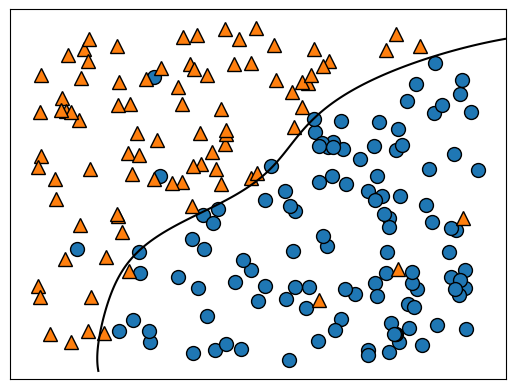

In [27]:
svc_classifier_plot(random_svc_classifier, Xval, yval, .05)

### Обучение SVC классификатора с `C = 0.3` и `gamma = 100`

In [28]:
random_svc_classifier = fit_svc_classifier(X, y, "rbf", 0.3, 100)

Score: 0.95260663507109


### Результат работы SVC классификатора на тренировочной выборке

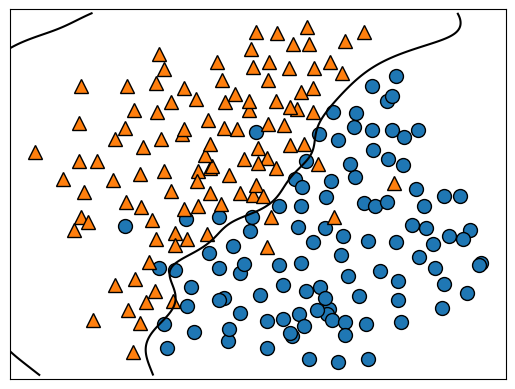

In [29]:
svc_classifier_plot(random_svc_classifier, X, y, .05)

### Результат работы SVC классификатора на тестовой выборке

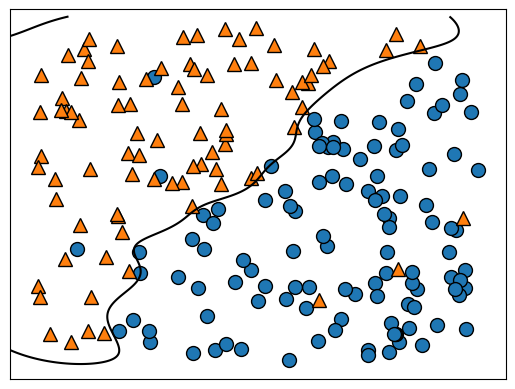

In [30]:
svc_classifier_plot(random_svc_classifier, Xval, yval, .05)